### CNN(Convolution Neural Network) 예측모델

In [5]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

In [6]:
# tensorflow 손글씨 데이터셋 로드
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

# 훈련용(정답 포함), 태스트용(정답 포함) 60,000개 데이터셋 로드

In [7]:
train_input.shape

# 3차원(60000면, 28행, 28열)

(60000, 28, 28)

In [8]:
# (60000, 28, 28) 원본 데이터
# 흑백의 채널을 정규화
# -1 : 가변 데이터, 알아서 값을 셋팅(tensorflow가 수행)
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0  # (데이터개수, 행, 열, 채널(흑백:1채널, 컬러:3채널(RGB))) -> 0,1사이의 값으로 정규화

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(train_scaled, train_target, test_size=0.2,  # 80% 학습용, 검증용 20%
                 random_state=42)

In [9]:
# CNN(합성곱) 신경망 구성
# Convolution 2D

model = keras.Sequential()
# 입력 레이어 구성
model.add(keras.Input(shape=(28, 28, 1)))  # 28행, 28열, 1채널 : 3차원 shape  

# CNN(합성곱) 알고리즘 적용
# Hyper 파라미터 처리(filters, kernel_size, padding, strides)
# 합성곱 연산의 처리 흐름(배치 처리) 
model.add(keras.layers.Conv2D(filters=32, 
                              kernel_size=(3, 3),
                              padding='same',  # padding : 입력값 주변을 특정값으로 채우는 것, same : Conv2D가 알아서 동일한 입력 사이즈의 크기만큼 출력이 되도록 설정해줌
                              strides=1,  # 스트라이드 : 다음 연산을 위해서 얼마나 shift할 것인지 셋팅, 디폴트는 1
                              activation='relu' # 학습을 위한 활성화 함수, relu 함수 : 정확도 측명에서 최근에 많이 사용, n개의 클래스인 경우 softmax, 바이너리인 경우는 sigmoid 함수
                              ))   

# AveragePooling2D()
# pooling 레이어 계층을 추가
model.add(keras.layers.MaxPool2D(pool_size=(2, 2))) 


In [10]:
# 신경망 추가 : 두번째 레이어 추가
model.add(keras.layers.Conv2D(filters=64, 
                              kernel_size=(3, 3),
                              padding='same',  # padding : 입력값 주변을 특정값으로 채우는 것, same : Conv2D가 알아서 동일한 입력 사이즈의 크기만큼 출력이 되도록 설정해줌
                              strides=1,  # 스트라이드 : 다음 연산을 위해서 얼마나 shift할 것인지 셋팅, 디폴트는 1
                              activation='relu' # 학습을 위한 활성화 함수, relu 함수 : 정확도 측명에서 최근에 많이 사용, n개의 클래스인 경우 softmax, 바이너리인 경우는 sigmoid 함수
                              ))   

# AveragePooling2D()
# pooling 레이어 계층을 추가
model.add(keras.layers.MaxPool2D(pool_size=(2, 2))) 

In [11]:
# 완전 연결 계층(Affine 계층)으로 연결
# 입력 레이어
model.add(keras.layers.Flatten())  # 입력은 1차원 형태로 펼침, model.add(keras.layers.MaxPool2D(pool_size=(2, 2))) 의 결과

model.add(keras.layers.Dense(units=100, activation='relu'))  # 입력으로 전달 받은 데이터를 몇개의 노드로 출력 레이어로 연결할지 지정, 활성화 함수 : 
model.add(keras.layers.Dropout(0.4)) # Dropout 알고리즘, 모든 노드를 학습 시키는 것이 아니라 랜덤하게 40% 노드는 drop

# 마지막 출력 레이어
model.add(keras.layers.Dense(units=10, activation='softmax')) # 클래스의 갯수가 2개 이상인 경우


In [ ]:
model.summary()

# 레이어별 계산 상세
# 1. conv2d (Conv2D) : 320개
    # 입력: MNIST 데이터 형태인 (28, 28, 1)로 계산된 모델 (입력 채널 수 = 1)
    # 커널(필터) 크기: 3 * 3
    # 출력 채널 수 : 32
    # 계산
        # (3 * 3 * 1 + 1) * 32 = 320
# 2. max_pooling2d (MaxPooling2D) : 0개
# 3. conv2d_1 (Conv2D) : 18,496개    
    # (3 * 3 * 32 + 1) * 64 = 18496

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
## 참고 - 위와 동일 코드
# model = keras.Sequential([
#     keras.Input(shape=(28, 28, 1)),
#     keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
#     keras.layers.MaxPooling2D((2, 2)),
#     keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
#     keras.layers.MaxPooling2D((2, 2)),
#     keras.layers.Flatten(),
#     keras.layers.Dense(100, activation='relu'),
#     keras.layers.Dropout(0.4),
#     keras.layers.Dense(10, activation='softmax')
# ])

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',  # 정답 데이터는 정수값,
              optimizer='adam',  # 최적화 알고리즘으로 adam
              metrics=['accuracy']) # 정확도 계산

In [ ]:
# 학습 진행
accuracy = model.fit(train_scaled, train_target, epochs=50, 
                     batch_size=100, verbose=1,    # verbose=1 출력 결과가 보임
                     validation_data=(val_scaled, val_target))

In [ ]:
model.evaluate(val_scaled, val_target)  # 학습에 한번도 사용하지 않은 검증 데이터 사용

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9240 - loss: 0.4545


[0.4544793963432312, 0.9240000247955322]

In [ ]:
# ModelCheckpoint() 최적의 알고리즘을 찾으면 저장(완성된 모델)
# EarlyStopping() 손실이 더 적어지거나 더 커지지 않도록 조기 종료(patience=2  : 2번만 실행)

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.h5',
                                             save_best_only=True)  # save_best_only 완성된 모델을 저장

early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, 
                                      restore_best_weights=True)
# 예측 모델이 생성 되는 순간의 필터값
# 저장된 최적의 모델을 호출해서 해당 모델이 예측
history = model.fit(train_scaled, train_target, epochs=100,
                      validation_data=(val_scaled, val_target), 
                      callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
1492/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9749 - loss: 0.0656

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9749 - loss: 0.0657 - val_accuracy: 0.9221 - val_loss: 0.4087
Epoch 2/100
1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9755 - loss: 0.0644

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9755 - loss: 0.0647 - val_accuracy: 0.9200 - val_loss: 0.3881
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9768 - loss: 0.0622

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9768 - loss: 0.0622 - val_accuracy: 0.9186 - val_loss: 0.3838
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9755 - loss: 0.0644 - val_accuracy: 0.9222 - val_loss: 0.4062
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9783 - loss: 0.0573 - val_accuracy: 0.9240 - val_loss: 0.4273


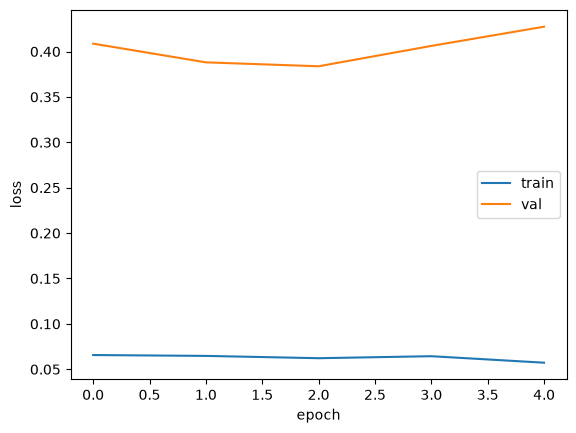

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0  # 한번도 학습시에 사용하지 않은 태스트 데이터, 10000개 이미지

model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9137 - loss: 0.4414


[0.44142574071884155, 0.9136999845504761]

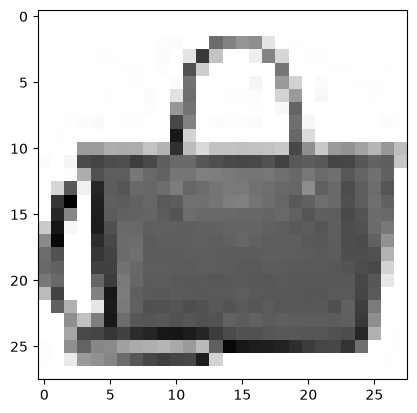

In [23]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()